In [6]:
import re

import ftfy
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
TARGET_CLASSES = ['Depression', 'Suicidal', 'Normal', 'Joy', 'Stress', 'Anxiety']

MENTAL_HEALTH_PATH = '../data/raw/Combined Data.csv'
SUICIDE_PATH = '../data/raw/Suicide_Detection.csv'
EMOTIONS_TRAIN_PATH = '../data/raw/emotions_nlp_train.txt'
EMOTIONS_VAL_PATH = '../data/raw/emotions_nlp_val.txt'
EMOTIONS_TEST_PATH = '../data/raw/emotions_nlp_test.txt'
CANCER_PATH = '../data/raw/cancer_mental_health.csv'

print('Target classes:', TARGET_CLASSES)

Target classes: ['Depression', 'Suicidal', 'Normal', 'Joy', 'Stress', 'Anxiety']


# Color map for each emotion

In [8]:
COLOR_MAP = {
    'Depression': '#1f77b4',   
    'Suicidal': '#d62728',  
    'Normal': '#2ca02c',       
    'Joy': '#ffcc00',         
    'Stress': '#ff7f0e',       
    'Anxiety': '#9467bd'       
}


# Text cleaning functions

In [ ]:
def fix_encoding(text):
    if not isinstance(text, str):
        return text
    text = ftfy.fix_text(text)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]', '', text)
    text = re.sub(r' {2,}', ' ', text)
    return text.strip()

def quick_clean(df, text_col='text'):
    #Drop any nulls, clean text, and filter out very short posts
    df = df.dropna(subset=[text_col]).copy()
    df[text_col] = df[text_col].astype(str).apply(fix_encoding)
    df = df[df[text_col].str.split().str.len() >= 10]
    return df

# Load and Clean each dataset

In [10]:
#Mental Health Dataset
mh_df = pd.read_csv(MENTAL_HEALTH_PATH)
mh_df = mh_df.rename(columns={
    'statement': 'text', 'status': 'label', 'Mental Health Status': 'label'
})
mh_df = mh_df[['text', 'label']].copy()
mh_df['label'] = mh_df['label'].str.strip()
mh_df = mh_df[mh_df['label'].isin(TARGET_CLASSES)]
mh_df = quick_clean(mh_df)
print(f'Dataset 1 (Mental Health): {len(mh_df):,} rows')
print(mh_df['label'].value_counts().to_string())
print()

#SuicideWatch Dataset
sw_df = pd.read_csv(SUICIDE_PATH)
sw_df = sw_df.rename(columns={'post': 'text', 'class': 'orig_label', 'label': 'orig_label'})
sw_df = sw_df[sw_df['orig_label'].str.lower().str.strip() == 'suicide']
sw_df['label'] = 'Suicidal'
sw_df = quick_clean(sw_df)
sw_df = sw_df[['text', 'label']]

#Limit SuicideWatch dataset to 25,000
mh_suicidal = len(mh_df[mh_df['label'] == 'Suicidal'])
target_suicidal = 25_000
sw_budget = max(target_suicidal - mh_suicidal, 0)
if len(sw_df) > sw_budget:
    sw_df = sw_df.sample(n=sw_budget, random_state=42)

print(f'Dataset 2 (SuicideWatch): {len(sw_df):,} rows')
print(sw_df['label'].value_counts().to_string())
print()

#Emotions NLP dataset
em_train = pd.read_csv(EMOTIONS_TRAIN_PATH, sep=';', header=None, names=['text', 'label'])
em_val = pd.read_csv(EMOTIONS_VAL_PATH, sep=';', header=None, names=['text', 'label'])
em_test = pd.read_csv(EMOTIONS_TEST_PATH, sep=';', header=None, names=['text', 'label'])
em_df = pd.concat([em_train, em_val, em_test], ignore_index=True)
em_df = em_df[em_df['label'] == 'joy'].copy()
em_df['label'] = 'Joy'
em_df = quick_clean(em_df)
print(f'Dataset 3 (Emotions NLP - Joy): {len(em_df):,} rows')
print(em_df['label'].value_counts().to_string())
print()

#Cancer text dataset
cancer_df = pd.read_csv(CANCER_PATH)
text_col = [c for c in cancer_df.columns if 'text' in c.lower() or 'state' in c.lower() or 'post' in c.lower()]
TEXT_COL = text_col[0] if text_col else cancer_df.columns[0]
cancer_df = cancer_df.rename(columns={TEXT_COL: 'text'})
cancer_df = cancer_df[['text']].copy()
cancer_df = quick_clean(cancer_df)
cancer_df['text'] = cancer_df['text'].str.replace(r'http\S+', '', regex=True).str.strip()
cancer_df = cancer_df.drop_duplicates(subset=['text'])
print(f'Dataset 4 (Cancer vocab): {len(cancer_df):,} rows')

Dataset 1 (Mental Health): 39,940 rows
label
Depression    15104
Suicidal      10398
Normal         8325
Anxiety        3560
Stress         2553

Dataset 2 (SuicideWatch): 14,602 rows
label
Suicidal    14602

Dataset 3 (Emotions NLP - Joy): 5,506 rows
label
Joy    5506

Dataset 4 (Cancer vocab): 10,274 rows


# Plot individual datasets

In [11]:
def explore_datasetss(name, df, has_labels=True):
    word_counts = df['text'].str.split().str.len()
    
    print(f'{name}')
    print(f'Shape: {df.shape}')
    print(f'Text word count: min={word_counts.min()}, max={word_counts.max()}, mean={word_counts.mean():.1f}')
    print(f'Sample text: {df["text"].iloc[0][:150]}')
    print()
    
    if has_labels:
        counts = df['label'].value_counts()
        colors = [COLOR_MAP.get(label, 'gray') for label in counts.index]
        
        plt.figure(figsize=(8, 4))
        bars = plt.bar(counts.index, counts.values, color=colors)
        plt.title(f'{name} - Label Distribution')
        plt.xlabel('Class')
        plt.ylabel('Count')
        plt.xticks(rotation=30)
        
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', 
                     ha='center', va='bottom', fontsize=10)
        
        plt.tight_layout()
        plt.show()

Dataset 1: Mental Health
Shape: (39940, 2)
Text word count: min=10, max=6300, mean=130.9
Sample text: trouble sleeping, confused mind, restless heart. All out of tune



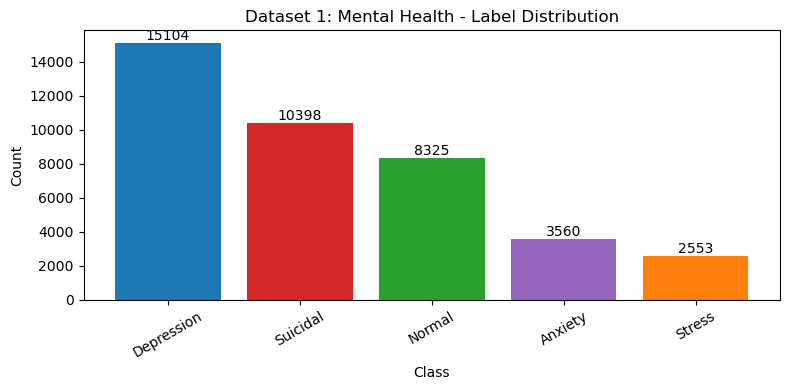

Dataset 2: SuicideWatch
Shape: (14602, 2)
Text word count: min=10, max=6781, mean=205.7
Sample text: Pls don't question people hereIf someone is talking to u about their struggles and stuff here pls don't question the credibility of their story. There



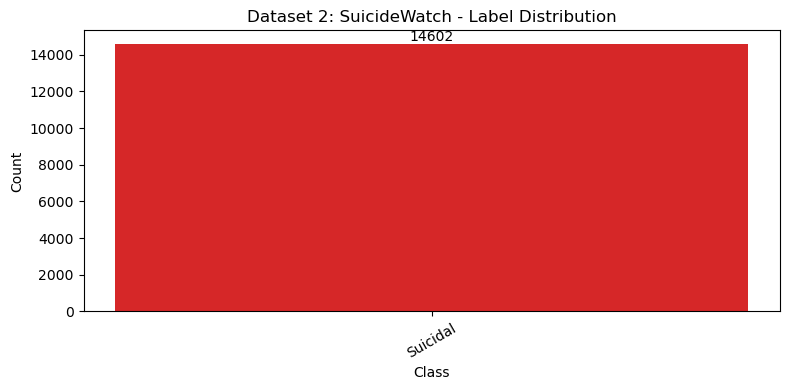

Dataset 3: Emotions NLP (Joy)
Shape: (5506, 2)
Text word count: min=10, max=64, mean=22.3
Sample text: i have been with petronas for years i feel that petronas has performed well and made a huge profit



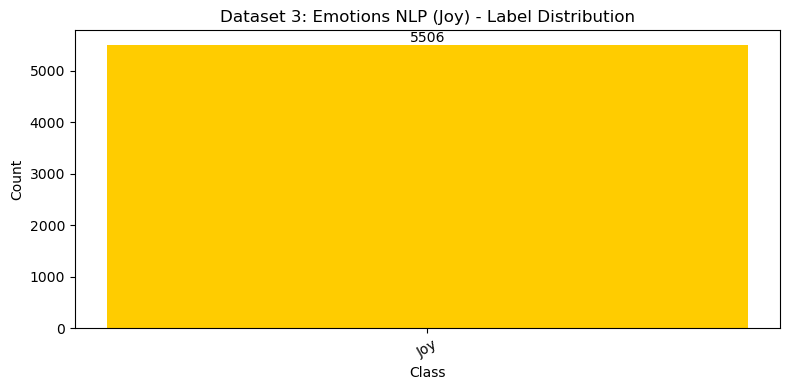

Dataset 4: Cancer Vocab
Shape: (10274, 1)
Text word count: min=10, max=5413, mean=236.7
Sample text: I know as parent of child with down syndrome that you have all hear that our child are at a high risk of leukemia as parent we read up on it and then 



In [12]:
explore_datasetss('Dataset 1: Mental Health', mh_df)
explore_datasetss('Dataset 2: SuicideWatch', sw_df)
explore_datasetss('Dataset 3: Emotions NLP (Joy)', em_df)
explore_datasetss('Dataset 4: Cancer Vocab', cancer_df, has_labels=False)

Rows: 59,206
Duplicates removed: 842
Missing values: 0

Combined Dataset
Shape: (59206, 2)
Text word count: min=10, max=6781, mean=139.0
Sample text: I don't know what to do.For the past few years my life has been in a downward spiral that doesn't seem to be coming to an end anytime soon. I'll start



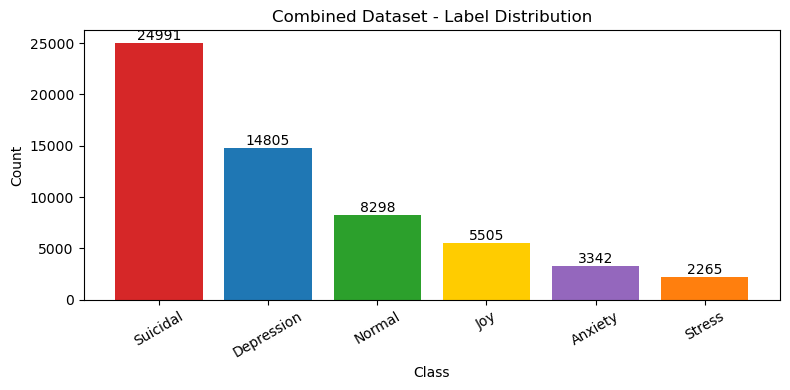

In [13]:
combined_df = pd.concat([mh_df, sw_df, em_df], ignore_index=True)
before_dedup = len(combined_df)

#Remove the duplicates and randomly shuffle the dataset
combined_df = combined_df.drop_duplicates(subset=['text'])
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)
combined_df = combined_df[['text', 'label']]

print(f'Rows: {len(combined_df):,}')
print(f'Duplicates removed: {before_dedup - len(combined_df):,}')
print(f'Missing values: {combined_df.isnull().sum().sum()}')
print()

explore_datasetss('Combined Dataset', combined_df)